## 1. Objective

The objective of this exploratory analysis is to understand customer characteristics, purchasing behavior, product preferences, promotional
activity, and subscription patterns within the prepared dataset.

The analysis focuses on identifying distributions, relationships, and patterns relevant to the defined business questions.

EDA is used to generate analytical observations and identify relationships that require further investigation. Formal statistical inference and
hypothesis testing are conducted separately in the Statistical Analysis stage.

## 2. Load Dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/processed/trendOne_clean.csv")

In [6]:
df.shape

(3900, 21)

In [7]:
df.head()

,customer_id,age,age_group,gender,item_purchased,category,purchase_amount_usd,location,region,size,...,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,previous_purchases_group,payment_method,frequency_of_purchases
0,1,55,55-64,Male,Blouse,Clothing,53,Kentucky,South,L,...,Winter,3.1,Yes,Express,Yes,Yes,14,11-20,Venmo,Fortnightly
1,2,19,18-24,Male,Sweater,Clothing,64,Maine,Northeast,L,...,Winter,3.1,Yes,Express,Yes,Yes,2,0-5,Cash,Fortnightly
2,3,50,45-54,Male,Jeans,Clothing,73,Massachusetts,Northeast,S,...,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,21+,Credit Card,Weekly
3,4,21,18-24,Male,Sandals,Footwear,90,Rhode Island,Northeast,M,...,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,21+,PayPal,Weekly
4,5,45,45-54,Male,Blouse,Clothing,49,Oregon,West,M,...,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,21+,PayPal,Annually


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               3900 non-null   int64  
 1   age                       3900 non-null   int64  
 2   age_group                 3900 non-null   str    
 3   gender                    3900 non-null   str    
 4   item_purchased            3900 non-null   str    
 5   category                  3900 non-null   str    
 6   purchase_amount_usd       3900 non-null   int64  
 7   location                  3900 non-null   str    
 8   region                    3900 non-null   str    
 9   size                      3900 non-null   str    
 10  color                     3900 non-null   str    
 11  season                    3900 non-null   str    
 12  review_rating             3863 non-null   float64
 13  subscription_status       3900 non-null   str    
 14  shipping_type      

## 3. EDA Approach

The exploratory analysis follows a progressive approach:

1. **Univariate analysis** is used to understand the distribution and
   composition of individual variables.

2. **Bivariate analysis** is used to explore relationships between customer
   characteristics, purchasing behavior, product categories, promotional
   activity, and subscription status.

3. **Multivariate exploration** is used where multiple variables provide
   additional context for observed patterns.

The variables and comparisons are selected based on the previously defined
business questions rather than applying visualizations indiscriminately
to every available variable.|

## 4. Univariate Analysis

### 4.1 Customer Demographic

### Age

In [14]:
df['age'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
age,3900.0,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0


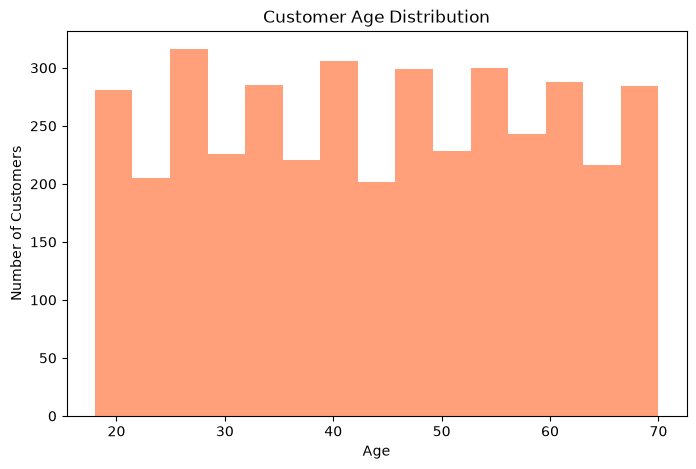

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=15,color="lightsalmon")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")
plt.show()

> The age distribution is pretty balanced across the range, with no single age interval having a huge concentration of customers. The data doesn't look heavily skewed toward younger or older groups either. Some brackets around the late 20s have slightly more people, but the difference is pretty small.

### Age group

In [18]:
df['age_group'].value_counts().sort_index()

age_group
18-24    486
25-34    755
35-44    729
45-54    752
55-64    751
65-70    427
Name: count, dtype: int64

In [144]:
df['age_group'].value_counts(normalize=True).sort_index().mul(100).round(2).to_frame()

,proportion
age_group,
18-24,12.46
25-34,19.36
35-44,18.69
45-54,19.28
55-64,19.26
65-70,10.95


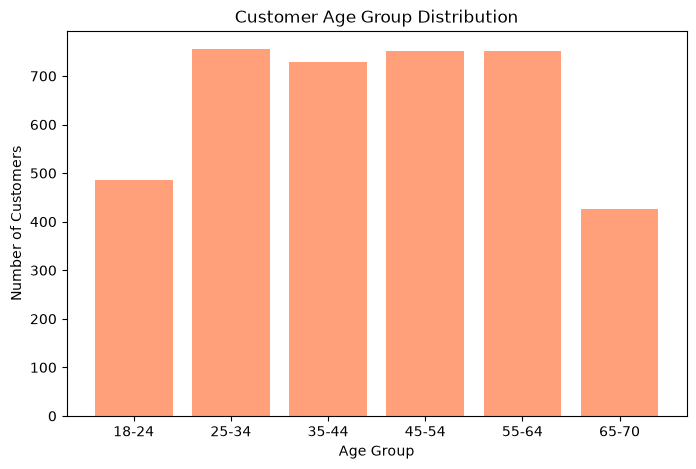

In [20]:
# df['age_group'].value_counts().sort_index().plot(kind="bar")


plt.figure(figsize=(8,5))
plt.bar(df['age_group'].value_counts().sort_index().index, df['age_group'].value_counts().sort_index().values, color="lightsalmon")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.title("Customer Age Group Distribution")
plt.show()

> As observed earlier, the late 20s age group tends to be slightly higher than other age intervals. This is also confirmed by the age group breakdown, where the 25–30 bracket has a fairly high customer count. However, the difference isn't very large compared to the other groups, as shown in the bar chart above.

### Gender

In [23]:
df['gender'].value_counts()

gender
Male      2652
Female    1248
Name: count, dtype: int64

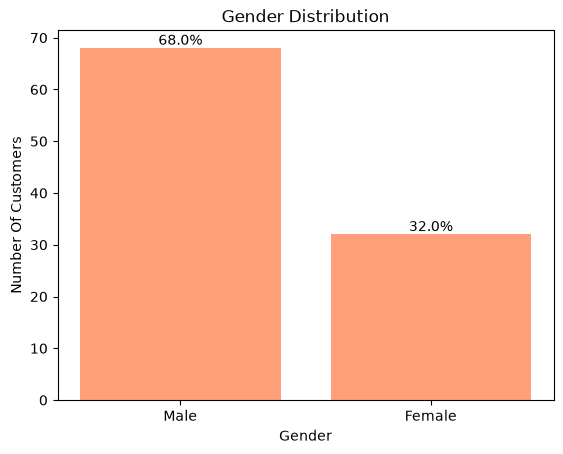

In [24]:
gender_percentage = (
    df['gender']
    .value_counts(normalize=True)
    .mul(100)
)

g_bars = plt.bar(gender_percentage.index, gender_percentage.values, color="lightsalmon")
plt.bar_label(g_bars, fmt='%.1f%%')

plt.xlabel("Gender")
plt.ylabel("Number Of Customers")
plt.title("Gender Distribution")
plt.show()

>The chart shows that TrendOne's customer base is predominantly male, with male customers accounting for 68% of the observations compared with 32% for female customers. The male customer share is therefore more than twice the female share, indicating a notable gender imbalance in the observed customer base.

### Region

In [27]:
df['region'].value_counts()

region
South        1271
West         1018
Midwest       937
Northeast     674
Name: count, dtype: int64

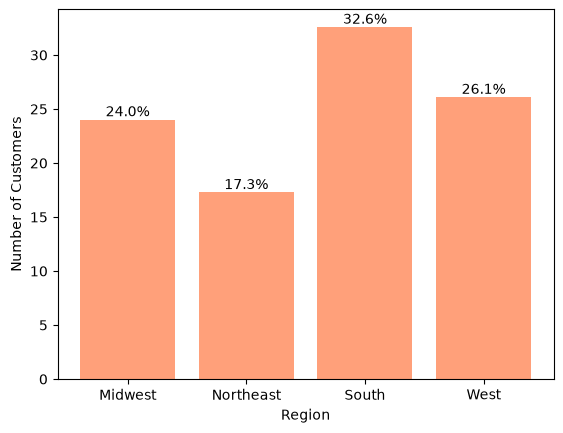

In [28]:
region_percentage = (
    df['region']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)
r_bars = plt.bar(region_percentage.index, region_percentage.values, color="lightsalmon")

plt.bar_label(r_bars, fmt='%.1f%%')
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.show()

>The bar chart shows that TrendOne's customers are mainly concentrated in the South region, which accounts for about 32.6% of the total.

### 4.2 Purchase Behavior

In [31]:
df['purchase_amount_usd'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
purchase_amount_usd,3900.0,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0


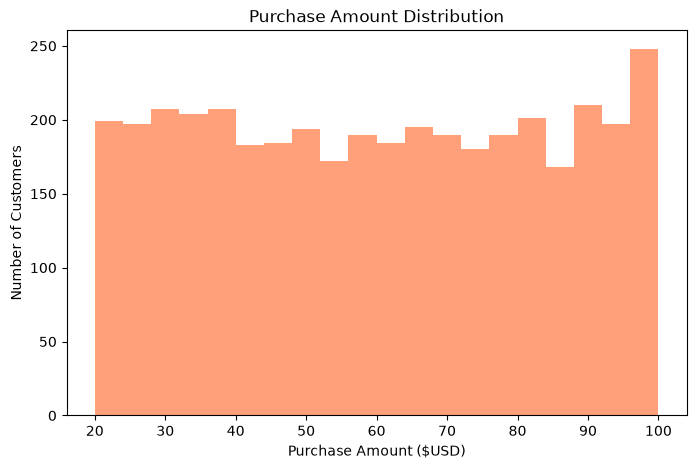

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df['purchase_amount_usd'], bins=20, color="lightsalmon")
plt.xlabel("Purchase Amount ($USD)")
plt.ylabel("Number of Customers")
plt.title("Purchase Amount Distribution")
plt.show()

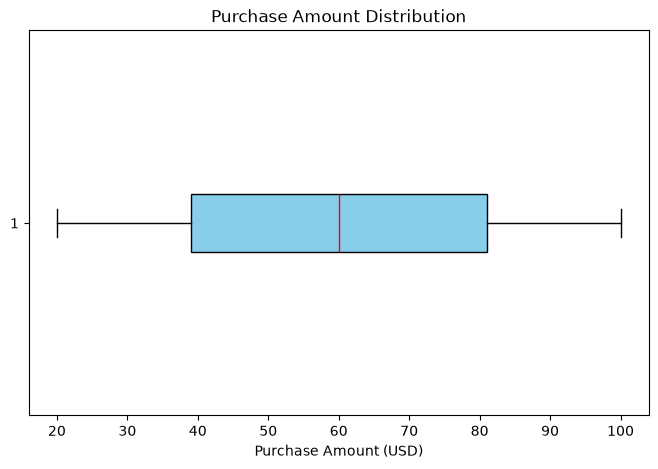

In [33]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df['purchase_amount_usd'], 
    orientation='horizontal',
    patch_artist=True,
    boxprops=dict(facecolor='skyblue'),
    medianprops=dict(color='red'))

plt.xlabel('Purchase Amount (USD)')
plt.title("Purchase Amount Distribution")
plt.show()

>The purchase amount distribution appears relatively symmetric, with the median located near the center of the interquartile range and similarly sized whiskers on both sides. No apparent outliers are observed based on the boxplot. The median purchase amount is approximately USD 60. However, the boxplot alone is not sufficient to determine whether the distribution follows a normal distribution.

### 4.3 Product Characteristics

### Product Categories

In [37]:
df['category'].value_counts()

category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

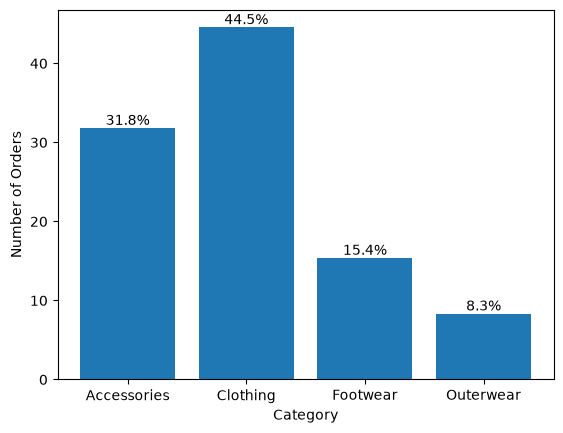

In [38]:
category_percentage = (
    df['category']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

c_bars = plt.bar(category_percentage.index, category_percentage.values)

plt.bar_label(c_bars, fmt='%.1f%%')
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.show()

>Most customers spend their money on the 'Clothing' category at TrendOne, contributing about 44.5%, while 'Outerwear' contributes the least at only around 8.3% overall.

### Top 10 Item Purchased

In [41]:
top_10_items = (
    df['item_purchased']
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_items.columns = columns = ['Item', 'Total']
top_10_items

,Item,Total
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


>The data shows that the most frequently purchased items are blouses, pants, and jewelry, all tied with a total of 171 purchases. The items ranked right below them have very similar purchase totals, showing little difference across categories.

### 4.4 Promotional & Subscription Characteristics

In [44]:
discount_percentage = df['discount_applied'].value_counts(normalize=True).mul(100).reset_index().sort_index(ascending=False)

discount_percentage.columns = columns = ['Discount Applied', 'Proportion (%)']
discount_percentage

,Discount Applied,Proportion (%)
1,Yes,43.0
0,No,57.0


>There is a notable difference in discount usage, with 43% of customers using a discount and 57% purchasing without one, a gap of 14% between the two groups.

In [46]:
subs_percentage = df['subscription_status'].value_counts(normalize=True).mul(100).reset_index().sort_index(ascending=False)

subs_percentage.columns = columns = ['Subscribed', 'Proportion (%)']
subs_percentage

,Subscribed,Proportion (%)
1,Yes,27.0
0,No,73.0


>There is a substantial difference in subscription status: 27% of customers are subscribed, while 73% are not.

## 5. Bivariate Analysis

### 5.1 Numerical Relationships

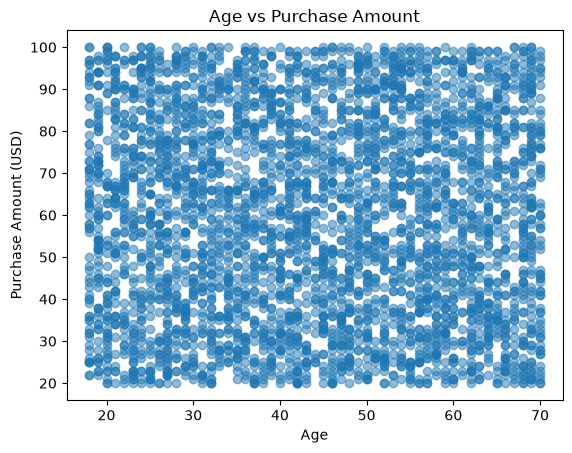

In [50]:
plt.scatter(
    df["age"],
    df["purchase_amount_usd"],
    alpha=0.5
)
plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")
plt.title("Age vs Purchase Amount")
plt.show()

>No clear visual relationship is observed between customer age and purchase amount. Purchase amounts are widely dispersed across the observed age range.

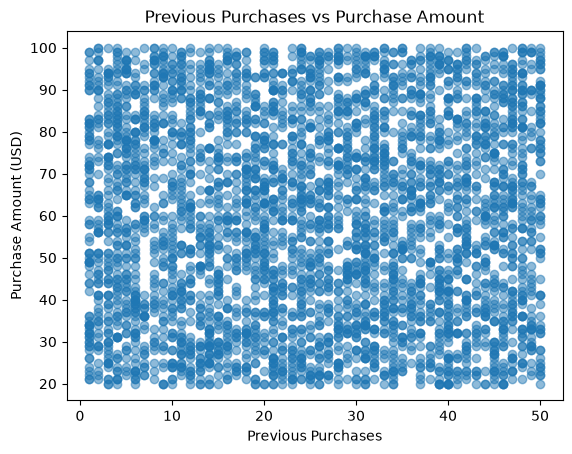

In [52]:
plt.scatter(
    df["previous_purchases"],
    df["purchase_amount_usd"],
    alpha=0.5
)
plt.xlabel("Previous Purchases")
plt.ylabel("Purchase Amount (USD)")
plt.title("Previous Purchases vs Purchase Amount")
plt.show()

>No clear visual relationship is observed between customer previous purchase and purchase amount. Purchase amounts are widely dispersed across the observed age range.

### 5.2 Purchase Value Across Customer Groups

### Age Group

In [56]:
df.groupby("age_group")['purchase_amount_usd'].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
age_group,,,,
18-24,486,60.201646,61.5,23.932820
25-34,755,60.132450,61.0,23.294299
35-44,729,59.620027,59.0,23.479993
45-54,752,60.332447,60.0,23.986983
55-64,751,58.716378,58.0,23.362950
65-70,427,59.704918,60.0,24.527594


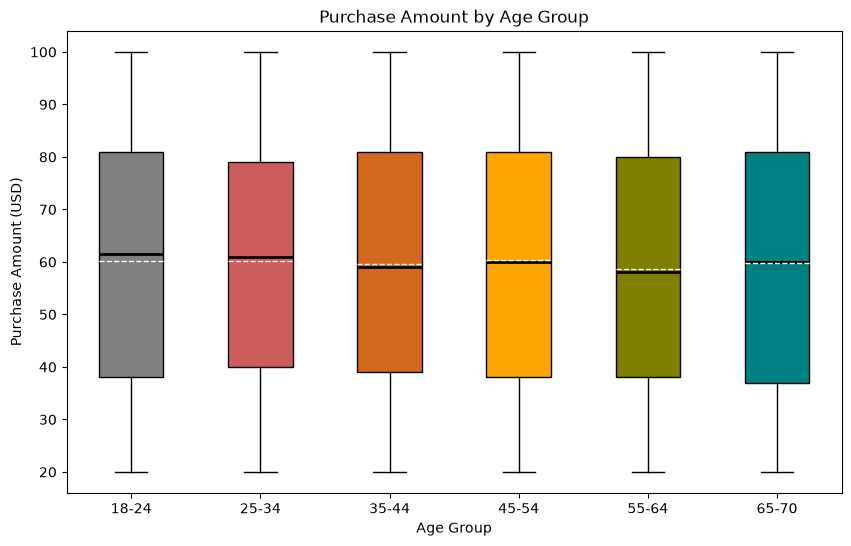

In [57]:
age_groups = sorted(df['age_group'].dropna().unique())

age_data_group = [df.loc[df['age_group'] == group, "purchase_amount_usd"] for group in age_groups]

colors = [
    "grey",
    "indianred",
    "chocolate",
    "orange",
    "olive",
    "teal"
]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    age_data_group,
    tick_labels=age_groups,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    showmeans=True,
    meanline=True,
    meanprops={'color': 'white'}
)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)

ax.set_title("Purchase Amount by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Purchase Amount (USD)")

plt.show()

>The analysis between age groups and purchase value shows no single age group standing out significantly from the others. The distribution looks fairly symmetrical, as the mean and median values are nearly identical.

### Gender

In [60]:
df.groupby("gender")['purchase_amount_usd'].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
gender,,,,
Female,1248,60.249199,60.0,23.420556
Male,2652,59.536199,60.0,23.809976


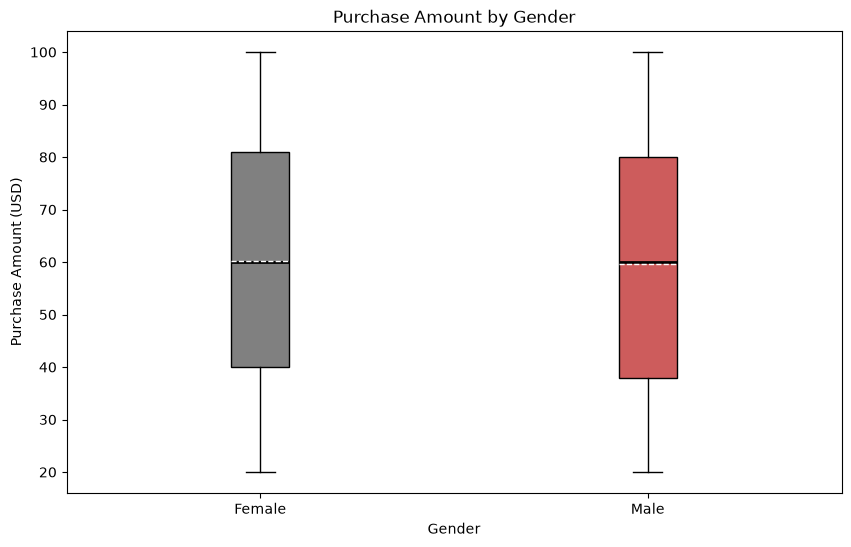

In [61]:
gender_groups = sorted(df['gender'].dropna().unique())

gender_data_group = [df.loc[df['gender'] == group, "purchase_amount_usd"] for group in gender_groups]

colors = [
    "grey",
    "indianred"
]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    gender_data_group,
    tick_labels=gender_groups,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    showmeans=True,
    meanline=True,
    meanprops={'color': 'white'}
)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)

ax.set_title("Purchase Amount by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Purchase Amount (USD)")

plt.show()

>Similarly, the gender analysis shows that purchase amounts are very close across groups, with no major differences, much like what we saw with the age groups.

### Region

In [64]:
df.groupby("region")['purchase_amount_usd'].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
region,,,,
Midwest,937,59.321238,60.0,24.104214
Northeast,674,59.247774,59.0,23.245624
South,1271,59.225020,58.0,23.740023
West,1018,61.187623,62.0,23.492654


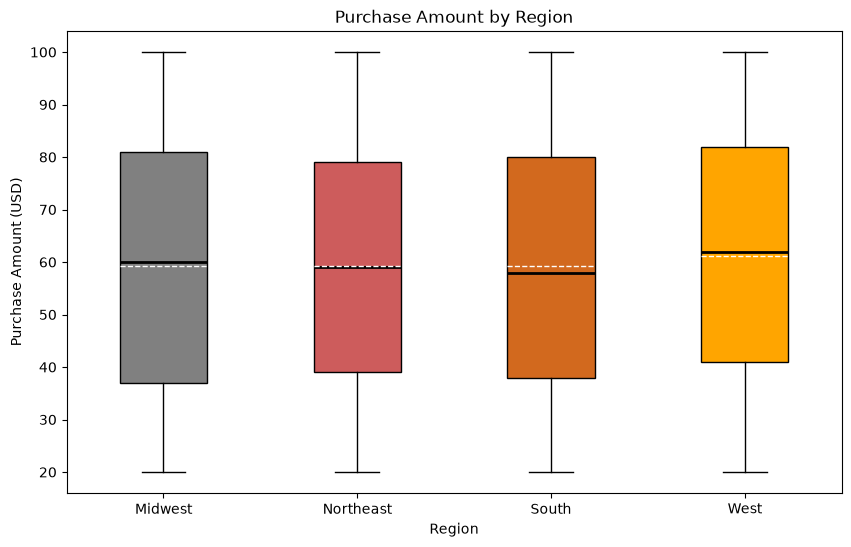

In [65]:
region_groups = sorted(df['region'].dropna().unique())

region_data_group = [df.loc[df['region'] == group, "purchase_amount_usd"] for group in region_groups]

colors = [
    "grey",
    "indianred",
    "chocolate",
    "orange"
]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    region_data_group,
    tick_labels=region_groups,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    showmeans=True,
    meanline=True,
    meanprops={'color': 'white'}
)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)

ax.set_title("Purchase Amount by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Purchase Amount (USD)")

plt.show()

>Purchase amounts show broadly similar distributions across the four regions, with substantial overlap in their interquartile ranges. The West has the highest median purchase amount, while the South has the lowest, although the differences appear relatively small from the boxplot alone. No apparent outliers are observed across the regions.

### 5.3 Product Category vs Purchase Behavior

In [69]:
df.groupby("category")['purchase_amount_usd'].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
category,,,,
Accessories,1240,59.838710,60.0,23.301230
Clothing,1737,60.025331,60.0,23.792460
Footwear,599,60.255426,60.0,23.638439
Outerwear,324,57.172840,54.5,24.590033


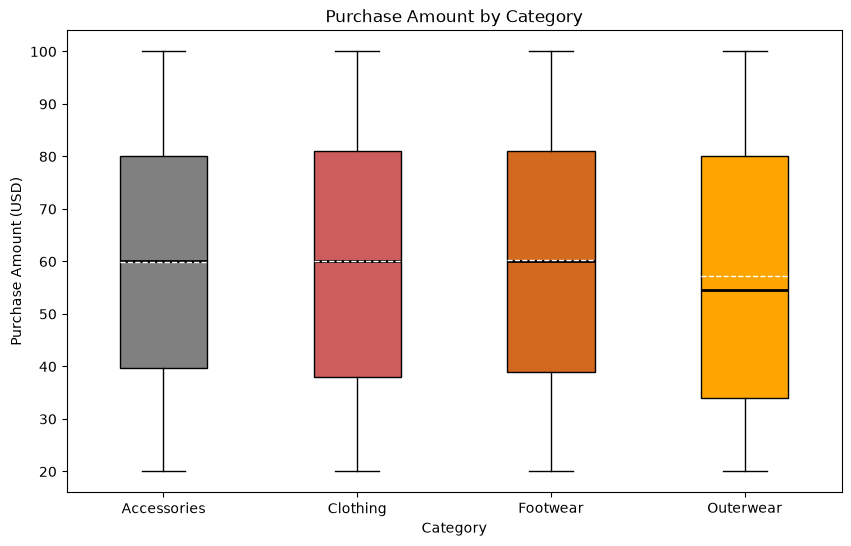

In [70]:
category_groups = sorted(df['category'].dropna().unique())

category_data_group = [df.loc[df['category'] == group, "purchase_amount_usd"] for group in category_groups]

colors = [
     "grey",
    "indianred",
    "chocolate",
    "orange"
]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    category_data_group,
    tick_labels=category_groups,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    showmeans=True,
    meanline=True,
    meanprops={'color': 'white'}
)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)

ax.set_title("Purchase Amount by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Purchase Amount (USD)")

plt.show()

In [71]:
df.groupby("category")['review_rating'].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
category,,,,
Accessories,1229,3.769976,3.8,0.716080
Clothing,1718,3.721537,3.7,0.718595
Footwear,594,3.793771,3.8,0.719222
Outerwear,322,3.745652,3.8,0.704323


In [72]:
df.groupby("category")['previous_purchases'].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
category,,,,
Accessories,1240,25.725806,26.0,14.541882
Clothing,1737,25.199194,25.0,14.308264
Footwear,599,25.232053,25.0,14.184094
Outerwear,324,24.956790,25.0,15.319244


>The category analysis shows no major differences in purchase amount, review rating, or previous purchases across categories—they all look very similar with none really standing out. The only exception is that the outerwear category has a slightly lower median purchase amount, and it also records the lowest sales volume, followed by footwear.

### 5.4 Discount Usage vs Purchase Behavior

In [74]:
df.groupby("discount_applied")['purchase_amount_usd'].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
discount_applied,,,,
No,2223,60.130454,60.0,23.740327
Yes,1677,59.279070,60.0,23.610697


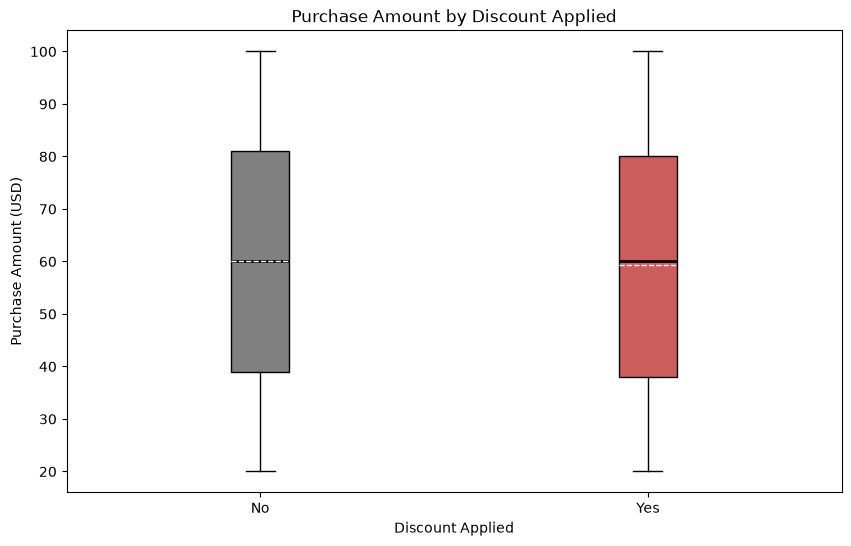

In [75]:
discount_groups = sorted(df['discount_applied'].dropna().unique())

discount_data_group = [df.loc[df['discount_applied'] == group, "purchase_amount_usd"] for group in discount_groups]

colors = [
     "grey",
    "indianred"
]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    discount_data_group,
    tick_labels=discount_groups,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    showmeans=True,
    meanline=True,
    meanprops={'color': 'white'}
)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)

ax.set_title("Purchase Amount by Discount Applied")
ax.set_xlabel("Discount Applied")
ax.set_ylabel("Purchase Amount (USD)")

plt.show()

In [76]:
df.groupby("discount_applied")['previous_purchases'].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
discount_applied,,,,
No,2223,25.056230,25.0,14.450885
Yes,1677,25.742993,25.0,14.437137


>Based on the analysis above, customers who use discounts and those who don't, have very similar mean and median purchase amounts. A similar pattern appears in previous purchases, where the mean and median are also quite close with no major differences between the two groups.

### 5.5 Subscription Status vs Purchase Behavior

In [78]:
df.groupby("subscription_status")['purchase_amount_usd'].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
subscription_status,,,,
No,2847,59.865121,60.0,23.775199
Yes,1053,59.491928,60.0,23.449914


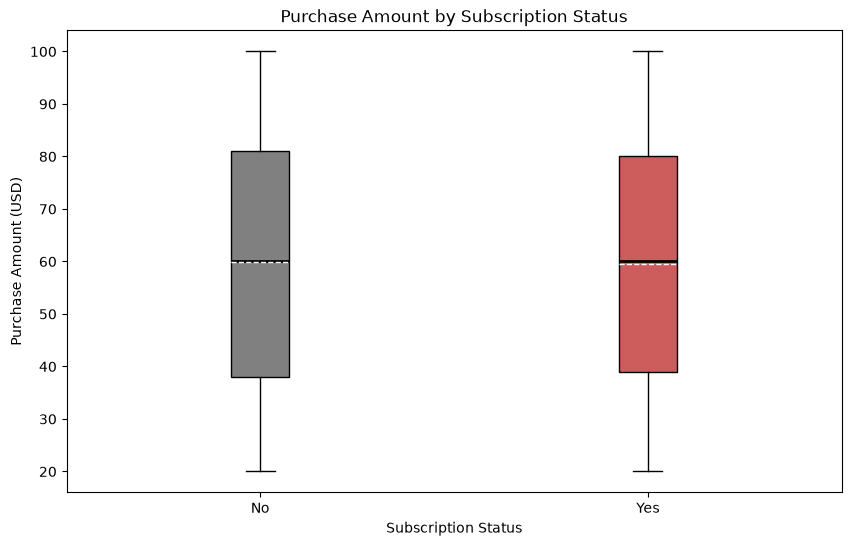

In [79]:
subscription_status_groups = sorted(df['subscription_status'].dropna().unique())

subscription_status_data_group = [df.loc[df['subscription_status'] == group, "purchase_amount_usd"] for group in subscription_status_groups]

colors = [
    "grey",
    "indianred"
]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    subscription_status_data_group,
    tick_labels=subscription_status_groups,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    showmeans=True,
    meanline=True,
    meanprops={'color': 'white'}
)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)

ax.set_title("Purchase Amount by Subscription Status")
ax.set_xlabel("Subscription Status")
ax.set_ylabel("Purchase Amount (USD)")

plt.show()

Based on the analysis of purchase amounts by subscription status, there is no real difference between subscribed and non-subscribed customers, as both their mean and median values are nearly identical.

In [81]:
pd.crosstab(
    df["subscription_status"],
    df["discount_applied"]
)

discount_applied,No,Yes
subscription_status,,
No,2223,624
Yes,0,1053


In [82]:
pd.crosstab(
    df["subscription_status"],
    df["discount_applied"],
    normalize="index"
).mul(100).round(2)

discount_applied,No,Yes
subscription_status,,
No,78.08,21.92
Yes,0.00,100.00


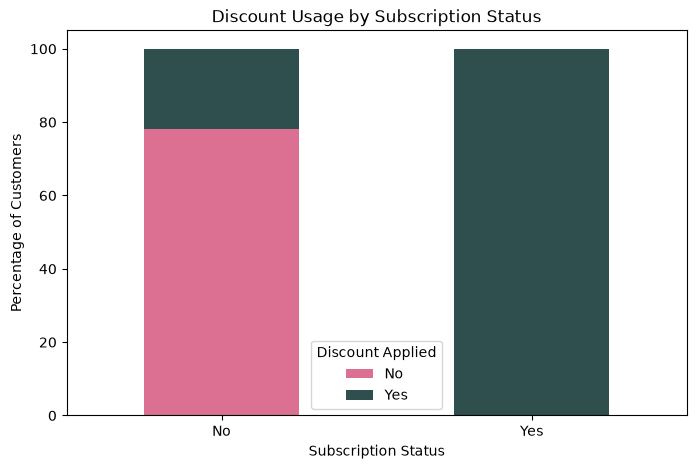

In [83]:
discount_by_subscription = pd.crosstab(
    df["subscription_status"],
    df["discount_applied"],
    normalize="index"
).mul(100).round(2)

discount_by_subscription.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=['palevioletred', 'darkslategray']
)

plt.title("Discount Usage by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Percentage of Customers")
plt.legend(title="Discount Applied")
plt.xticks(rotation=0)
plt.show()

## 6. Multivariate Analysis

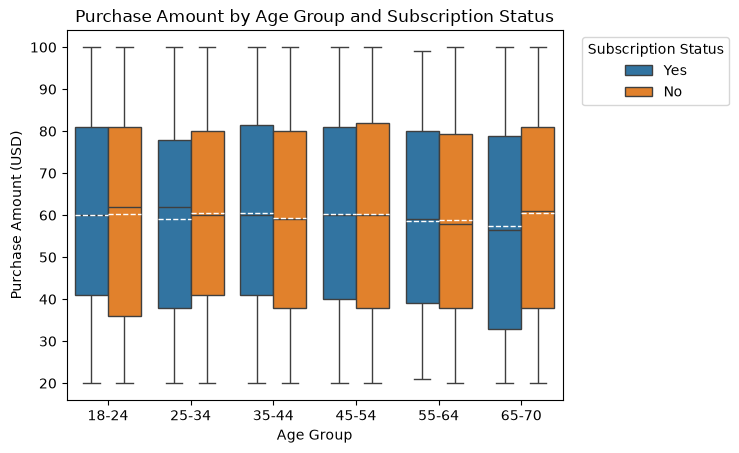

In [162]:
sns.boxplot(
    data=df,
    x="age_group",
    y="purchase_amount_usd",
    hue="subscription_status",
    order=age_groups,
    showmeans=True,
    meanline=True,
    meanprops={'color': 'white'}
)

plt.title("Purchase Amount by Age Group and Subscription Status")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount (USD)")
plt.legend(title="Subscription Status", bbox_to_anchor=(1.35, 1.0), loc=1)
plt.show()

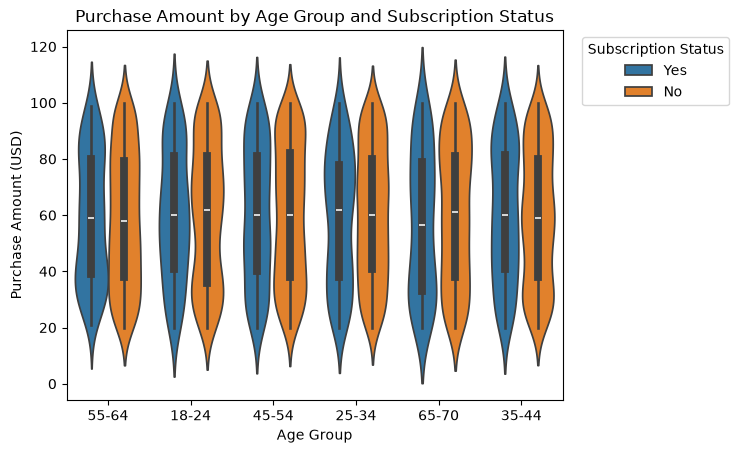

In [140]:
sns.violinplot(
    data=df,
    x="age_group",
    y="purchase_amount_usd",
    hue="subscription_status"
)

plt.title("Purchase Amount by Age Group and Subscription Status")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount (USD)")
plt.legend(title="Subscription Status", bbox_to_anchor=(1.35, 1.0), loc=1)
plt.show()

>Purchase amounts are quite similar across age groups and subscription status. Some groups show small differences in their median purchase amount, but there is no clear pattern across the groups.

>The differences between groups are relatively small compared to the variation within each group. Based on the chart, age group and subscription status do not clearly separate customers by purchase amount.

## 7. EDA Findings

The exploratory analysis resulted in the following observations:

- The customer base is relatively diverse in terms of age, although male customers make up a larger share of the dataset.

- Purchase amount does not show a clear visual relationship with age or previous purchase history.

- Purchase amounts are broadly similar across customer groups such as age group, gender, region, and subscription status, with considerable overlap between distributions.

- Purchase behavior across product categories also appears relatively similar, with no large differences in purchase amount or previous purchase history from the exploratory analysis.

- Customers who used discounts and those who did not show broadly similar purchase amount distributions.

- Subscription status and discount usage show a strong association in the observed data. All subscribed customers are recorded as having used a discount, while non-subscribed customers include both discount users and non-users.

## 8. Summary & Next Steps

The exploratory analysis provides an initial view of TrendOne customer characteristics and purchasing behavior. Most customer groups show similar purchase amount distributions, and no clear visual relationship was observed between purchase amount and age or previous purchase history.

The analysis also shows a strong relationship between subscription status and discount usage. However, this pattern should be interpreted carefully because all subscribed customers in the dataset are recorded as having used a discount.

Overall, the EDA does not show strong differences in purchase behavior across most of the examined customer groups. Further statistical analysis is therefore needed to determine whether the observed differences are statistically meaningful.

### Next Steps

The next stage will formally test selected relationships identified during the exploratory analysis, including:

- Whether purchase amount differs across relevant customer groups.
- Whether purchase amount differs across product categories.
- Whether discount usage is associated with differences in purchasing behavior.
- Whether subscription status is associated with purchasing behavior.
- Whether subscription status is associated with discount usage.

The results will be used to determine which observed patterns are supported by statistical evidence and which may simply reflect variation in the sample.